## 📦 준비물 - 한글 폰트 설정

- `matplotlib` 기본 폰트는 한글을 지원하지 않아요
- Attention Map에 한글이 깨지지 않도록 **나눔바른고딕** 폰트를 미리 설정합니다

In [1]:
# 필요한 라이브러리 불러오기
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm  # 폰트 관리 도구

# 그래프를 선명하게 출력하는 설정
%config InlineBackend.figure_format = 'retina'

# 한글 폰트 경로 지정
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

# 폰트 속성 설정
font = fm.FontProperties(fname=fontpath, size=9)

# matplotlib 전체에 한글 폰트 적용
plt.rc('font', family='NanumBarunGothic')

# 폰트 등록
mpl.font_manager.findfont(font)

# 정상 출력되면 성공!
print("숭=3")

숭=3


## 2. 내부 모듈 구현하기

### 📐 텐서 shape 변화 흐름
| 단계 | Shape |
|---|---|
| 입력 데이터 | `[batch_size x length]` |
| Embedding | `[batch_size x length x d_emb]` |
| Positional Encoding | shape 변화 없음 |
| Split Heads | `[batch_size x length x heads x (d_emb/n_heads)]` |
| Combine Heads | `[batch_size x length x d_emb]` |
| Feed-Forward | `[batch_size x length x d_ff]` |
| Output Linear | `[batch_size x length x vocab_size]` |

### 📦 필요한 라이브러리 import

In [2]:
# 수치 계산 라이브러리
import numpy as np

# 딥러닝 프레임워크 PyTorch
import torch
import torch.nn as nn                  # 신경망 레이어들
import torch.nn.functional as F        # 활성화함수 등 기능들
import torch.optim as optim            # 옵티마이저 (학습 알고리즘)

# 그래프 시각화
import matplotlib.pyplot as plt

# 텍스트 처리
import re      # 정규표현식 (문장 전처리용)
import os      # 파일/폴더 경로 관리
import io      # 입출력 처리

# 기타 유틸리티
import time    # 학습 시간 측정
import random  # 랜덤 샘플링
import math    # 수학 함수

# Attention Map 시각화용
import seaborn

# PyTorch 버전 확인 (정상 설치 확인용)
print(torch.__version__)

2.7.1+cu118


## 📍 Positional Encoding (위치 인코딩)

- Transformer는 RNN과 달리 단어 순서를 자동으로 알 수 없어요
- 그래서 **위치 정보를 직접 추가**해줘야 해요!
- sin/cos 함수를 이용해서 각 위치마다 고유한 값을 만들어줍니다

### 공식
- 짝수 인덱스 → sin 함수 적용
- 홀수 인덱스 → cos 함수 적용

In [4]:
def positional_encoding(pos, d_model):
    # pos      : 문장의 최대 길이 (단어 개수)
    # d_model  : 임베딩 차원 수

    def cal_angle(position, i):
        # 각 위치(position)와 차원(i)에 따른 각도 계산
        # 공식: position / 10000^(i/d_model)
        return position / np.power(10000, int(i) / d_model)

    def get_posi_angle_vec(position):
        # 하나의 위치에 대해 d_model 개의 각도값 리스트 반환
        return [cal_angle(position, i) for i in range(d_model)]

    # 모든 위치(0 ~ pos-1)에 대한 각도값 테이블 생성
    # shape: [pos x d_model]
    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    # 짝수 인덱스(0, 2, 4...) → sin 함수 적용
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])

    # 홀수 인덱스(1, 3, 5...) → cos 함수 적용
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table

print("슝=3")

슝=3


## 🧠 Multi-Head Attention

Transformer의 핵심 모듈! 입력을 여러 Head로 나눠서 동시에 Attention을 계산해요

### 구성 요소
| 함수 | 역할 |
|---|---|
| `split_heads()` | 입력을 Head 수만큼 분할 |
| `scaled_dot_product_attention()` | 각 Head에서 Attention 계산 |
| `combine_heads()` | 분할된 Head를 다시 하나로 합치기 |

### Shape 변화
- 입력: `[batch_size x length x d_model]`
- Split 후: `[batch_size x num_heads x length x depth]`
- Combine 후: `[batch_size x length x d_model]`

In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads   # Head 개수 (예: 8)
        self.d_model = d_model       # 임베딩 차원 수 (예: 512)

        # 각 Head가 담당하는 차원 수
        # 예: d_model=512, num_heads=8 이면 depth=64
        self.depth = d_model // self.num_heads

        # Q, K, V 각각을 위한 Linear Layer
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종 출력을 위한 Linear Layer
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask):
        # K의 마지막 차원 크기 (= depth)
        d_k = K.size(-1)

        # Q와 K를 곱해서 Attention Score 계산
        # Q: [batch x heads x length x depth]
        # K.T: [batch x heads x depth x length]
        # QK: [batch x heads x length x length]
        QK = torch.matmul(Q, K.transpose(-2, -1))

        # Score를 sqrt(d_k)로 나눠서 스케일 조정
        # (값이 너무 커지면 gradient 소실 문제 발생!)
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있으면 해당 위치에 매우 작은 값(-1e9) 추가
        # Softmax 통과 후 해당 위치의 Attention이 0에 가까워짐
        if mask is not None:
            scaled_qk += (mask * -1e9)

        # Softmax로 Attention 가중치 계산 (합이 1이 되도록)
        attentions = F.softmax(scaled_qk, dim=-1)

        # Attention 가중치와 V를 곱해서 최종 출력
        out = torch.matmul(attentions, V)
        return out, attentions

    def split_heads(self, x):
        batch_size = x.size(0)

        # [batch x length x d_model]
        # → [batch x length x num_heads x depth]
        x = x.view(batch_size, -1, self.num_heads, self.depth)

        # → [batch x num_heads x length x depth]
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        batch_size = x.size(0)

        # [batch x num_heads x length x depth]
        # → [batch x length x num_heads x depth]
        x = x.permute(0, 2, 1, 3)

        # → [batch x length x d_model]
        x = x.contiguous().view(batch_size, -1, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        # Q, K, V 각각에 Linear Layer 적용
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        # 각각을 num_heads 개로 분할
        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled Dot Product Attention 계산
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask)

        # 분할된 Head를 다시 하나로 합치기
        out = self.combine_heads(out)

        # 최종 Linear Layer 통과
        out = self.linear(out)
        return out, attention_weights

print("슝=3")

슝=3


## ⚡ Position-wise Feed-Forward Network (FFN)

Multi-Head Attention 이후에 적용되는 레이어예요!
각 위치(position)마다 **독립적으로** 같은 FFN을 적용합니다

### 구조
- `w_1`: d_model(512) → d_ff(2048) 로 차원 확장
- `ReLU`: 활성화 함수 적용
- `w_2`: d_ff(2048) → d_model(512) 로 차원 복원

### Shape 변화
- 입력: `[batch x length x 512]`
- w_1 통과 후: `[batch x length x 2048]`
- w_2 통과 후: `[batch x length x 512]` ← 원래대로!

In [6]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()

        # 첫 번째 Linear Layer: 차원 확장
        # d_model(512) → d_ff(2048)
        self.w_1 = nn.Linear(d_model, d_ff)

        # 두 번째 Linear Layer: 차원 복원
        # d_ff(2048) → d_model(512)
        self.w_2 = nn.Linear(d_ff, d_model)

        # 활성화 함수: 음수는 0으로, 양수는 그대로
        self.relu = nn.ReLU()

    def forward(self, x):
        # 1단계: w_1으로 차원 확장 후 ReLU 적용
        out = self.relu(self.w_1(x))

        # 2단계: w_2로 차원 복원
        out = self.w_2(out)

        return out

print("슝=3")

슝=3


## 🔧 3. 모듈 조립하기

### 💡 핵심 아이디어
- EncoderLayer, DecoderLayer를 `nn.Module`로 정의하면
- 아래처럼 원하는 수만큼 레이어를 쉽게 쌓을 수 있어요!

```python

In [7]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()

        # Multi-Head Attention 모듈 (아까 만든 클래스 재사용!)
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)

        # Feed-Forward Network 모듈 (아까 만든 클래스 재사용!)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # Layer Normalization (학습 안정화용)
        # eps: 분모가 0이 되는 것을 방지하는 아주 작은 값
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)  # Attention 전 Norm
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)  # FFN 전 Norm

        # Dropout (과적합 방지)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):

        # ---- Multi-Head Attention 블록 ----
        residual = x                              # 잔차연결을 위해 입력 저장
        out = self.norm_1(x)                      # 1. LayerNorm 먼저
        out, enc_attn = self.enc_self_attn(       # 2. Self-Attention
            out, out, out, mask)                  #    (Q=K=V=자기자신)
        out = self.dropout(out)                   # 3. Dropout
        out += residual                           # 4. 잔차연결 (입력 더하기)

        # ---- Feed-Forward Network 블록 ----
        residual = out                            # 잔차연결을 위해 저장
        out = self.norm_2(out)                    # 1. LayerNorm 먼저
        out = self.ffn(out)                       # 2. FFN 통과
        out = self.dropout(out)                   # 3. Dropout
        out += residual                           # 4. 잔차연결

        return out, enc_attn

print("슝=3")

슝=3


## 🔧 DecoderLayer 구현

### Encoder vs Decoder 차이점
| | Encoder | Decoder |
|---|---|---|
| Attention 횟수 | 1번 | **2번** |
| Self-Attention | ✅ | ✅ (Masked) |
| Encoder-Decoder Attention | ❌ | ✅ |
| Norm 개수 | 2개 | **3개** |
| 반환 Attention | 1개 | **2개** |

### Decoder Attention 흐름
1. **Masked Self-Attention**: 디코더 자기 자신끼리 (미래 단어 못 보게 마스킹!)
2. **Encoder-Decoder Attention**: 인코더 출력을 참고 (번역할 때 원문 참고!)
3. **FFN**: 각 위치별 특징 학습

In [8]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()

        # 1️⃣ Masked Self-Attention: 디코더 입력끼리의 Attention
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)

        # 2️⃣ Encoder-Decoder Attention: 인코더 출력을 참고하는 Attention
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)

        # FFN 모듈
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # LayerNorm 3개 (Attention 블록이 2개라 Encoder보다 1개 더 필요!)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)  # Masked Self-Attention 전
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)  # Enc-Dec Attention 전
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)  # FFN 전

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, causality_mask, padding_mask):
        # x            : 디코더 입력
        # enc_out      : 인코더 출력 (원문 정보)
        # causality_mask : 미래 단어를 못 보게 막는 마스크
        # padding_mask : 패딩 토큰을 무시하는 마스크

        # ---- 1️⃣ Masked Self-Attention 블록 ----
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(
            out, out, out, padding_mask)   # Q=K=V=자기자신, 패딩마스크 적용
        out = self.dropout(out)
        out += residual

        # ---- 2️⃣ Encoder-Decoder Attention 블록 ----
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(
            out, enc_out, enc_out, causality_mask)  # Q=디코더, K=V=인코더출력
        out = self.dropout(out)
        out += residual

        # ---- 3️⃣ FFN 블록 ----
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        # Attention 2개 반환 (Encoder는 1개였지만 Decoder는 2개!)
        return out, dec_attn, dec_enc_attn

print("슝=3")

슝=3


## 🏗️ Encoder & Decoder 클래스 조립

### 💡 핵심 개념: nn.ModuleList
- 여러 레이어를 리스트처럼 관리하는 PyTorch 도구
- 일반 파이썬 리스트와 달리 **PyTorch가 레이어를 인식**할 수 있어요!

```python

In [9]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()

        self.n_layers = n_layers  # 쌓을 레이어 수 (논문 기본값: 6)

        # n_layers 개의 EncoderLayer를 한 번에 생성!
        # nn.ModuleList: 파이썬 리스트처럼 사용하지만
        # PyTorch가 내부 레이어들을 모델로 인식할 수 있게 해줘요
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, mask):
        out = x
        enc_attns = []  # 각 레이어의 Attention 저장 (시각화용)

        # n_layers 번 반복하며 레이어를 차례로 통과
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)  # 레이어별 Attention 저장

        # out       : 최종 인코더 출력 → 디코더로 전달됨
        # enc_attns : 모든 레이어의 Attention 리스트 → 시각화용
        return out, enc_attns

print("슝=3")

슝=3


## 🏗️ Decoder 클래스 조립

### Encoder vs Decoder 클래스 차이
| | Encoder | Decoder |
|---|---|---|
| 입력 | x, mask | x, enc_out, causality_mask, padding_mask |
| 반환 Attention | 1개 (enc_attns) | **2개** (dec_attns, dec_enc_attns) |

### Decoder 동작 흐름
입력 → DecoderLayer 1 → DecoderLayer 2 → ... → DecoderLayer N → 출력

### 저장하는 Attention 2종류
- `dec_attns` : Masked Self-Attention (디코더 자기 자신)
- `dec_enc_attns` : Encoder-Decoder Attention (원문 참고)

In [10]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()

        self.n_layers = n_layers  # 쌓을 레이어 수 (논문 기본값: 6)

        # n_layers 개의 DecoderLayer를 한 번에 생성!
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, causality_mask, padding_mask):
        # x              : 디코더 입력 (번역 중인 문장)
        # enc_out        : 인코더 출력 (원문 정보)
        # causality_mask : 미래 단어 못 보게 막는 마스크
        # padding_mask   : 패딩 토큰 무시하는 마스크

        out = x
        dec_attns = []      # Masked Self-Attention 저장 (시각화용)
        dec_enc_attns = []  # Encoder-Decoder Attention 저장 (시각화용)

        # n_layers 번 반복하며 레이어를 차례로 통과
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = \
                self.dec_layers[i](out, enc_out, causality_mask, padding_mask)

            dec_attns.append(dec_attn)      # 레이어별 Self-Attention 저장
            dec_enc_attns.append(dec_enc_attn)  # 레이어별 Enc-Dec Attention 저장

        # out           : 최종 디코더 출력
        # dec_attns     : 모든 레이어의 Self-Attention 리스트
        # dec_enc_attns : 모든 레이어의 Enc-Dec Attention 리스트
        return out, dec_attns, dec_enc_attns

print("슝=3")

슝=3


## 🎉 Transformer 최종 완성!

### 전체 구조 한눈에 보기
입력 → Embedding + Positional Encoding → Encoder → Decoder → Linear → 출력

### 💡 2가지 핵심 포인트

#### 1. Weight Sharing (가중치 공유)
- `shared=True` 이면 Decoder Embedding과 출력 Linear의 Weight를 공유
- 파라미터 수를 줄여서 학습 효율을 높여줘요!
- Weight 공유 시 Embedding 값에 `sqrt(d_model)` 을 곱해줘야 해요

#### 2. Positional Encoding shape 맞추기
- positional_encoding 반환: `[Length x d_model]`
- Embedding 출력: `[Batch x Length x d_model]`
- `.unsqueeze(0)` 으로 Batch 차원 추가 → `[1 x Length x d_model]`
- 브로드캐스팅으로 자동으로 Batch 크기에 맞춰져요!

In [11]:
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,       # 인코더/디코더 레이어 수
                 d_model,        # 임베딩 차원 (논문: 512)
                 n_heads,        # Attention Head 수 (논문: 8)
                 d_ff,           # FFN 내부 차원 (논문: 2048)
                 src_vocab_size, # 소스(한국어) 단어 사전 크기
                 tgt_vocab_size, # 타겟(영어) 단어 사전 크기
                 pos_len,        # Positional Encoding 최대 길이
                 dropout=0.2,    # Dropout 비율
                 shared=True):   # Embedding & Linear Weight 공유 여부
        super(Transformer, self).__init__()

        self.d_model = float(d_model)

        # 소스(한국어) 임베딩
        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        # 타겟(영어) 임베딩
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # Positional Encoding 미리 계산해서 저장
        self.pos_encoding = self.positional_encoding(pos_len, d_model)

        self.dropout = nn.Dropout(dropout)

        # 인코더 & 디코더
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        # 최종 출력 Linear Layer: d_model → tgt_vocab_size
        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared = shared

        # 💡 Weight Sharing
        # Decoder Embedding과 출력 Linear의 weight를 동일하게 설정
        # 파라미터 수를 줄여서 학습 효율 향상!
        if shared:
            self.fc.weight = self.dec_emb.weight

    def positional_encoding(self, pos_len, d_model):
        # 위치값 생성: [pos_len x 1]
        position = torch.arange(0, pos_len).unsqueeze(1).float()

        # 각도 계산을 위한 분모값
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            -(torch.log(torch.tensor(10000.0)) / d_model)
        )

        # pos_encoding 초기화: [pos_len x d_model]
        pos_encoding = torch.zeros(pos_len, d_model)

        # 짝수 인덱스 → sin, 홀수 인덱스 → cos
        pos_encoding[:, 0::2] = torch.sin(position * div_term)
        pos_encoding[:, 1::2] = torch.cos(position * div_term)

        return pos_encoding  # shape: [pos_len x d_model]

    def embedding(self, emb, x):
        seq_len = x.size(1)

        out = emb(x)  # shape: [Batch x Length x d_model]

        # 💡 Weight Sharing 시 sqrt(d_model) 곱하기
        # Embedding 값이 너무 작아지는 것을 보정!
        if self.shared:
            out *= torch.sqrt(torch.tensor(self.d_model))

        # 💡 shape 맞추기
        # pos_encoding: [Length x d_model]
        # .unsqueeze(0) → [1 x Length x d_model]
        # 브로드캐스팅으로 Batch 크기에 자동으로 맞춰짐!
        out += self.pos_encoding[:seq_len, :].unsqueeze(0)

        out = self.dropout(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_mask):
        # 1. Embedding + Positional Encoding
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)

        # 2. Encoder 통과
        enc_out, enc_attns = self.encoder(enc_in, enc_mask)

        # 3. Decoder 통과 (인코더 출력도 함께 전달!)
        dec_out, dec_attns, dec_enc_attns = \
            self.decoder(dec_in, enc_out, causality_mask, dec_mask)

        # 4. 최종 Linear Layer → vocab_size 크기의 logits 출력
        logits = self.fc(dec_out)

        # logits        : 예측값 [Batch x Length x tgt_vocab_size]
        # enc_attns     : 인코더 Attention (시각화용)
        # dec_attns     : 디코더 Self-Attention (시각화용)
        # dec_enc_attns : 디코더 Enc-Dec Attention (시각화용)
        return logits, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


## 4. 모델 밖의 조력자들

### 🎭 Masking 종류 2가지

#### 1. Padding Mask
- 문장마다 길이가 달라서 짧은 문장은 0으로 채워요 (패딩)
- 이 0(패딩)을 Attention에서 **무시**하도록 마스킹!

#### 2. Causality Mask (인과 마스크)
- 디코더에서 **미래 단어를 못 보게** 막는 마스크
- 번역할 때 아직 생성 안 된 단어를 미리 보면 안 되니까요!

### 마스크 생성 흐름

In [13]:
import torch
import numpy as np

def generate_padding_mask(seq):
    # seq: [Batch x Length]
    # 패딩(0)인 위치를 1로 표시
    mask = (seq == 0).float()

    # [Batch x 1 x 1 x Length] 로 shape 변환
    # Attention 연산 시 브로드캐스팅 되도록!
    return mask.unsqueeze(1).unsqueeze(2)

def generate_causality_mask(size):
    # 상삼각행렬 생성 (대각선 위쪽이 1)
    # diagonal=1: 대각선 자체는 0, 그 위쪽만 1
    # shape: [size x size]
    mask = torch.triu(torch.ones(size, size), diagonal=1)
    return mask

def generate_masks(src, tgt):
    # 1. 인코더용 패딩 마스크 (한국어 입력의 패딩 무시)
    enc_mask = generate_padding_mask(src)

    # 2. 디코더 Enc-Dec Attention용 패딩 마스크 (영어 타겟의 패딩 무시)
    dec_enc_mask = generate_padding_mask(tgt)

    # 3. 디코더 Self-Attention용 Causality 마스크 (미래 단어 차단)
    seq_len = tgt.shape[-1]
    causal_mask = generate_causality_mask(seq_len)

    # Batch 크기만큼 복제: [Batch x 1 x seq_len x seq_len]
    batch_size = src.shape[0]
    dec_mask = causal_mask.expand(batch_size, 1, seq_len, seq_len)

    # enc_mask    : 인코더 패딩 마스크
    # dec_enc_mask: 디코더 Enc-Dec Attention 패딩 마스크
    # dec_mask    : 디코더 Causality 마스크
    return enc_mask, dec_enc_mask, dec_mask

print("슝=3")

슝=3


## 👁️ 마스크 시각화로 확인하기

### 각 마스크가 어떻게 생겼는지 눈으로 확인해보자!

| 마스크 | 설명 |
|---|---|
| Encoder Mask | 패딩(0) 위치만 밝게 표시 |
| Encoder-Decoder Mask | 타겟 패딩 위치 표시 |
| Decoder Mask | 미래 단어 차단 (삼각형 모양!) |

### 샘플 데이터 설정
- batch=16, length=20
- src_padding=5 → 뒤에 0이 5개
- tgt_padding=15 → 뒤에 0이 15개

findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Fo

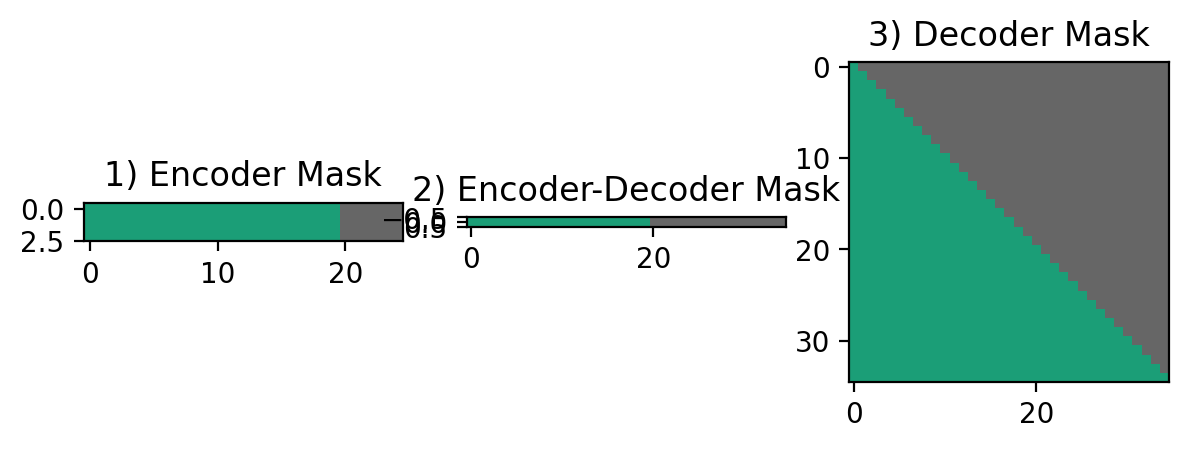

In [14]:
import matplotlib.pyplot as plt

# 샘플 데이터 설정
batch, length = 16, 20
src_padding = 5   # 소스 문장 패딩 길이
tgt_padding = 15  # 타겟 문장 패딩 길이

# 실제 데이터(1)와 패딩(0) 생성
sample_data = torch.ones((batch, length))    # 실제 토큰: 1로 채움
src_pad = torch.zeros((batch, src_padding))  # 소스 패딩: 0으로 채움
tgt_pad = torch.zeros((batch, tgt_padding))  # 타겟 패딩: 0으로 채움

# 실제 데이터 뒤에 패딩 붙이기
# sample_src shape: [16 x 25] (20개 실제 + 5개 패딩)
# sample_tgt shape: [16 x 35] (20개 실제 + 15개 패딩)
sample_src = torch.cat([sample_data, src_pad], dim=-1)
sample_tgt = torch.cat([sample_data, tgt_pad], dim=-1)

# 마스크 생성
enc_mask, dec_enc_mask, dec_mask = generate_masks(sample_src, sample_tgt)

# 시각화
fig = plt.figure(figsize=(7, 7))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.set_title('1) Encoder Mask')
ax2.set_title('2) Encoder-Decoder Mask')
ax3.set_title('3) Decoder Mask')

# enc_mask: 첫 3개 배치의 패딩 위치 확인
ax1.imshow(enc_mask[:3, 0, 0].numpy(), cmap='Dark2')

# dec_enc_mask: 타겟 패딩 위치 확인
ax2.imshow(dec_enc_mask[0, 0].numpy(), cmap='Dark2')

# dec_mask: 미래 단어 차단 삼각형 모양 확인
ax3.imshow(dec_mask[0, 0].numpy(), cmap='Dark2')

plt.show()

## 📈 Learning Rate Scheduler

### 왜 고정 Learning Rate를 안 쓰나요?
- 처음엔 **작게** 시작해서 천천히 올리고 (Warmup)
- 일정 step 이후엔 **서서히 줄여나가요**
- 이렇게 하면 학습이 더 안정적이에요!

### 수식
`lr = d_model^(-0.5) × min(step^(-0.5), step × warmup_steps^(-1.5))`

### Learning Rate 변화
- **warmup 구간** (step < 4000): 점점 증가 📈
- **warmup 이후** (step > 4000): 점점 감소 📉

### Optimizer 설정 (논문 그대로!)
| 파라미터 | 값 |
|---|---|
| Optimizer | Adam |
| beta1 | 0.9 |
| beta2 | 0.98 |
| epsilon | 1e-9 |

In [15]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000):
        # d_model      : 모델 차원 수 (논문: 512)
        # warmup_steps : LR을 올리다가 내리기 시작하는 기준 step (논문: 4000)
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = torch.tensor(step, dtype=torch.float32)

        # arg1: step이 커질수록 작아지는 항 (warmup 이후 적용)
        arg1 = step ** -0.5

        # arg2: step이 커질수록 커지는 항 (warmup 구간 적용)
        arg2 = step * (self.warmup_steps ** -1.5)

        # 둘 중 작은 값을 선택
        # → warmup 구간: arg2가 작으므로 LR 증가
        # → warmup 이후: arg1이 작으므로 LR 감소
        return (self.d_model ** -0.5) * torch.minimum(arg1, arg2)

# 테스트용 더미 모델 (실제 Transformer 학습 때는 Transformer 모델로 교체!)
model = nn.Linear(10, 10)

# Adam Optimizer (논문에 정의된 파라미터 그대로!)
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-9,          # 초기 LR (Scheduler가 덮어씌울 거라 작게 설정)
    betas=(0.9, 0.98),# beta1=0.9, beta2=0.98
    eps=1e-9          # 수치 안정성을 위한 작은 값
)

print("슝=3")

슝=3


## 5. 프로젝트: 더 멋진 번역기 만들기

### 📦 라이브러리 버전 확인
본격적인 프로젝트 시작 전에
사용할 라이브러리 버전을 확인해요!

In [16]:
import torch
import numpy
import matplotlib

# 각 라이브러리 버전 출력
print(torch.__version__)        # PyTorch 버전
print(numpy.__version__)        # NumPy 버전
print(matplotlib.__version__)   # Matplotlib 버전

2.7.1+cu118
2.2.6
3.10.3


## 📥 Step 1. 데이터 다운로드

한국어-영어 병렬 데이터를 다운로드해요
(한국어 문장과 영어 번역문이 쌍으로 이루어진 데이터!)

In [17]:
# 데이터 저장할 폴더 생성
!mkdir -p ~/work/transformer/data

# 데이터 다운로드
!wget https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz -P ~/work/transformer/data

# 압축 해제 1단계: .gz 풀기
!gzip -d ~/work/transformer/data/korean-english-park.train.tar.gz

# 압축 해제 2단계: .tar 풀기
!tar -xvf ~/work/transformer/data/korean-english-park.train.tar -C ~/work/transformer/data

--2026-05-13 05:07:16--  https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz [following]
--2026-05-13 05:07:17--  https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8718893 (8.3M) [application/octet-stream]
Saving to: ‘/home/jovyan/work/transformer/data/korean-e

## 🧹 Step 2. 데이터 정제

### 하는 일
- 한국어 파일(.ko)과 영어 파일(.en)을 읽어요
- 중복된 문장 쌍을 제거해요!

### 💡 중복 제거 방법
- `set()` : 중복을 허용하지 않는 데이터형
- 한국어-영어 쌍을 탭(`\t`)으로 연결한 후 set에 넣으면
- 자동으로 중복 제거!

### 예시

In [18]:
# 데이터 파일 경로 설정
data_dir = os.path.join(os.getenv("HOME"), 'work/transformer/data')
kor_path = data_dir + "/korean-english-park.train.ko"  # 한국어 파일
eng_path = data_dir + "/korean-english-park.train.en"  # 영어 파일

def clean_corpus(kor_path, eng_path):
    # 한국어 파일 읽기 (한 줄 = 한 문장)
    with open(kor_path, "r") as f:
        kor = f.read().splitlines()

    # 영어 파일 읽기 (한 줄 = 한 문장)
    with open(eng_path, "r") as f:
        eng = f.read().splitlines()

    # 한국어와 영어 문장 수가 같은지 확인!
    # 다르면 에러 발생 → 데이터 문제 있다는 신호
    assert len(kor) == len(eng)

    # 핵심: 한국어\t영어 형태로 묶은 후 set()으로 중복 제거
    # list()로 다시 변환해서 인덱싱 가능하게!
    cleaned_corpus = list(set([
        "\t".join([k, e]) for k, e in zip(kor, eng)
    ]))

    return cleaned_corpus

cleaned_corpus = clean_corpus(kor_path, eng_path)

# 결과 확인
print(f"총 문장 쌍 수: {len(cleaned_corpus)}")
print(f"예시: {cleaned_corpus[0]}")

총 문장 쌍 수: 78968
예시: 클린턴의 남편인 빌 클린턴 전 대통령은 지난 1월 사우스캐롤라이나 경선 당시 “흑인이 많은 이 지역에서 흑인이 이기는 것은 당연하다”며 오바마의 승리를 인종주의에 따른 결과로 치부했다.	Clinton was asked about remarks her husband, former President Bill Clinton, made while on the trail for his wife in South Carolina last month in which he seemed to imply that Obama's success in South Carolina would largely be based on his race.


## ✂️ Step 2-2. 문장 정제 함수

### 정제 순서
1. 모든 문자를 **소문자**로 변환
2. 알파벳, 한글, 문장부호 **이외 제거** (숫자, 특수문자 등)
3. 문장부호 양옆에 **공백 추가** (토큰으로 분리되도록)
4. 중복 공백 제거 & 앞뒤 공백 제거

### 예시

In [19]:
def preprocess_sentence(sentence):
    # 1. 모든 문자 소문자로 변환
    # "Hello" → "hello"
    sentence = sentence.lower()

    # 2. 알파벳, 한글, 문장부호(?.!,) 이외 모두 공백으로 치환
    # 숫자, 특수문자 등 제거
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)

    # 3. 문장부호 양옆에 공백 추가
    # "hello,world" → "hello , world"
    # 나중에 토큰으로 잘 분리되도록!
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

    # 4. 여러 개의 공백을 하나로 합치고 앞뒤 공백 제거
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = sentence.strip()

    return sentence

# 테스트
print(preprocess_sentence("Hello, 안녕하세요!!  123"))
print(preprocess_sentence("I love Python & 딥러닝!"))

hello , 안녕하세요 ! !
i love python 딥러닝 !


## 🔤 Step 2-3. 토큰화 (SentencePiece)

### SentencePiece란?
- Google이 만든 토크나이저
- 언어에 상관없이 **자주 나오는 단어 조각**으로 분리해요
- 한국어처럼 형태소가 복잡한 언어에도 잘 작동해요!

### 특수 토큰 인덱스
| 토큰 | 역할 | 인덱스 |
|---|---|---|
| `<PAD>` | 문장 길이 맞추기용 빈 토큰 | 0 |
| `<BOS>` | 문장 시작 (Begin Of Sentence) | 1 |
| `<EOS>` | 문장 끝 (End Of Sentence) | 2 |
| `<UNK>` | 모르는 단어 (Unknown) | 3 |

### 💡 영어 토크나이저에만 BOS/EOS 추가하는 이유
- 디코더 입력은 `<BOS>` 로 시작해서 `<EOS>` 로 끝나야 해요
- 인코더(한국어)는 필요 없어요!

In [21]:
# sentencepiece 설치
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 9.8 MB/s eta 0:00:00ta 0:00:01


In [22]:
def generate_tokenizer(corpus,
                        vocab_size,
                        lang="ko",
                        pad_id=0,
                        bos_id=1,
                        eos_id=2,
                        unk_id=3):

    # 말뭉치를 텍스트 파일로 저장 (SentencePiece는 파일을 입력으로 받아요)
    file = "./%s_corpus.txt" % lang
    model = "%s_spm" % lang

    with open(file, 'w') as f:
        for row in corpus:
            f.write(str(row) + '\n')

    # SentencePiece 학습
    import sentencepiece as spm
    spm.SentencePieceTrainer.Train(
        '--input=./%s --model_prefix=%s --vocab_size=%d' \
        % (file, model, vocab_size) + \
        ' --pad_id=%d --bos_id=%d --eos_id=%d --unk_id=%d' \
        % (pad_id, bos_id, eos_id, unk_id)
        # input     : 학습할 텍스트 파일
        # model_prefix : 저장될 모델 파일 이름
        # vocab_size   : 단어 사전 크기
        # pad/bos/eos/unk_id : 특수 토큰 인덱스 지정
    )

    # 학습된 모델 불러오기
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load('%s.model' % model)
    return tokenizer

# 단어 사전 크기 설정
SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 20000

# 한국어/영어 말뭉치 분리 & 정제
eng_corpus = []
kor_corpus = []
for pair in cleaned_corpus:
    k, e = pair.split("\t")
    kor_corpus.append(preprocess_sentence(k))  # 한국어 정제
    eng_corpus.append(preprocess_sentence(e))  # 영어 정제

# 토크나이저 생성
ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")

# 영어 토크나이저에만 BOS/EOS 추가
# 디코더 입력이 <BOS>로 시작해서 <EOS>로 끝나도록!
en_tokenizer.set_encode_extra_options("bos:eos")

print("슝=3")

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=././ko_corpus.txt --model_prefix=ko_spm --vocab_size=20000 --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ././ko_corpus.txt
  input_format: 
  model_prefix: ko_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id:

슝=3


G(INFO) Final character coverage=0.999909
trainer_interface.cc(594) LOG(INFO) Done! preprocessed 78956 sentences.
unigram_model_trainer.cc(265) LOG(INFO) Making suffix array...
unigram_model_trainer.cc(269) LOG(INFO) Extracting frequent sub strings... node_num=5609877
unigram_model_trainer.cc(312) LOG(INFO) Initialized 82992 seed sentencepieces
trainer_interface.cc(600) LOG(INFO) Tokenizing input sentences with whitespace: 78956
trainer_interface.cc(611) LOG(INFO) Done! 44562
unigram_model_trainer.cc(602) LOG(INFO) Using 44562 sentences for EM training
unigram_model_trainer.cc(618) LOG(INFO) EM sub_iter=0 size=34535 obj=9.86221 num_tokens=83351 num_tokens/piece=2.41352
unigram_model_trainer.cc(618) LOG(INFO) EM sub_iter=1 size=25851 obj=8.00619 num_tokens=83809 num_tokens/piece=3.242
unigram_model_trainer.cc(618) LOG(INFO) EM sub_iter=0 size=21976 obj=7.92354 num_tokens=84710 num_tokens/piece=3.85466
unigram_model_trainer.cc(618) LOG(INFO) EM sub_iter=1 size=21846 obj=7.90462 num_token

## 📊 Step 2-4. 데이터셋 구축 & 텐서 변환

### 하는 일
1. 토큰 길이가 **50 이하**인 문장만 선별 (너무 긴 문장 제거!)
2. 토큰 ID로 변환 후 **텐서**로 만들기
3. 길이가 다른 문장들을 **패딩**으로 길이 맞추기

### 💡 패딩(Padding)이란?
- 배치 안의 문장들은 길이가 다 달라요
- 짧은 문장 뒤에 0을 채워서 길이를 맞춰줘요
- 예시:

In [23]:
import torch
import torch.nn.functional as F
from tqdm.notebook import tqdm  # 진행률 표시 바

src_corpus = []  # 한국어 토큰 리스트
tgt_corpus = []  # 영어 토큰 리스트

# 한국어/영어 문장 수가 같은지 확인
assert len(kor_corpus) == len(eng_corpus)

# 토큰 길이가 50 이하인 문장만 선별
for idx in tqdm(range(len(kor_corpus))):
    # 문장을 토큰 ID 리스트로 변환
    src_tokens = ko_tokenizer.encode_as_ids(kor_corpus[idx])
    tgt_tokens = en_tokenizer.encode_as_ids(eng_corpus[idx])

    # 둘 다 50 이하인 경우만 추가
    if len(src_tokens) <= 50 and len(tgt_tokens) <= 50:
        src_corpus.append(torch.tensor(src_tokens, dtype=torch.long))
        tgt_corpus.append(torch.tensor(tgt_tokens, dtype=torch.long))

def pad_sequences(sequences, padding_value=0):
    # 길이가 다른 텐서들을 패딩으로 길이 맞추기
    # batch_first=True : [Batch x Length] 형태로 반환
    return torch.nn.utils.rnn.pad_sequence(
        sequences,
        batch_first=True,
        padding_value=padding_value
    )

# 패딩 처리 완료 → 학습용 텐서 완성!
enc_train = pad_sequences(src_corpus, padding_value=0)  # 한국어
dec_train = pad_sequences(tgt_corpus, padding_value=0)  # 영어

# shape 확인
# [전체 문장 수 x 최대 토큰 길이] 형태여야 해요
print(enc_train.shape, dec_train.shape)

  0%|          | 0/78968 [00:00<?, ?it/s]

torch.Size([72107, 50]) torch.Size([72107, 50])


## 🏗️ Step 3. 모델 설계

### Transformer 하이퍼파라미터 (논문 기본값 참고)
| 파라미터 | 설명 | 값 |
|---|---|---|
| `n_layers` | 인코더/디코더 레이어 수 | 6 |
| `d_model` | 임베딩 차원 수 | 512 |
| `n_heads` | Attention Head 수 | 8 |
| `d_ff` | FFN 내부 차원 | 2048 |
| `dropout` | 드롭아웃 비율 | 0.2 |
| `pos_len` | 최대 문장 길이 | 256 |

In [24]:
# 하이퍼파라미터 설정
N_LAYERS = 6       # 인코더/디코더 레이어 수
D_MODEL = 512      # 임베딩 차원 수
N_HEADS = 8        # Attention Head 수
D_FF = 2048        # FFN 내부 차원
DROPOUT = 0.2      # 드롭아웃 비율
POS_LEN = 256      # Positional Encoding 최대 길이

# GPU 사용 가능하면 GPU, 아니면 CPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

# Transformer 모델 생성
model = Transformer(
    n_layers=N_LAYERS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    src_vocab_size=SRC_VOCAB_SIZE,  # 한국어 단어 사전 크기
    tgt_vocab_size=TGT_VOCAB_SIZE,  # 영어 단어 사전 크기
    pos_len=POS_LEN,
    dropout=DROPOUT,
    shared=True                     # Embedding & Linear Weight 공유
).to(device)

# 모델 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters())
print(f"전체 파라미터 수: {total_params:,}")

사용 디바이스: cuda
전체 파라미터 수: 64,638,496


## 🚀 Step 4. 훈련하기

### 4-1. 모델 선언
- 빠른 학습을 위해 **2 Layer** 로 설정
- 나머지 하이퍼파라미터는 자유롭게 조절 가능!

### 하이퍼파라미터 설정값
| 파라미터 | 값 |
|---|---|
| `n_layers` | 2 (학습 속도를 위해 축소!) |
| `d_model` | 128 |
| `n_heads` | 8 |
| `d_ff` | 512 |
| `dropout` | 0.2 |

In [25]:
# 빠른 학습을 위해 작은 모델로 설정!
N_LAYERS = 2    # 레이어 수 (논문은 6, 여기선 2로 축소)
D_MODEL = 128   # 임베딩 차원 (논문은 512, 여기선 128로 축소)
N_HEADS = 8     # Attention Head 수
D_FF = 512      # FFN 내부 차원 (논문은 2048, 여기선 512로 축소)
DROPOUT = 0.2   # 드롭아웃 비율
POS_LEN = 256   # Positional Encoding 최대 길이

# GPU 사용 가능하면 GPU, 아니면 CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

# 2 Layer Transformer 모델 생성
model = Transformer(
    n_layers=N_LAYERS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=POS_LEN,
    dropout=DROPOUT,
    shared=True
).to(device)

# 모델 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters())
print(f"전체 파라미터 수: {total_params:,}")

사용 디바이스: cuda
전체 파라미터 수: 6,065,696


## 🔧 MultiHeadAttention 수정본

### 이전 버전과 달라진 점
| 항목 | 이전 | 수정 |
|---|---|---|
| d_model 체크 | 없음 | `assert` 로 오류 방지 추가 |
| 마스크 처리 | `mask * -1e9` 더하기 | `masked_fill` 로 더 안전하게 |
| combine_heads | 따로 shape 저장 안함 | shape 변수로 명확하게 |

In [1]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        # d_model이 num_heads로 나누어 떨어지는지 확인!
        # 예: d_model=128, num_heads=8 → depth=16 ✅
        # 예: d_model=100, num_heads=8 → 나누어 안떨어짐 ❌
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = K.shape[-1]

        # Q x K^T → Attention Score
        QK = torch.matmul(Q, K.transpose(-2, -1))

        # sqrt(d_k) 로 스케일 조정
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크 처리: masked_fill 사용 (더 안전!)
        # mask==0 인 위치를 -1e9 로 채움 → Softmax 후 0에 가까워짐
        if mask is not None:
            scaled_qk = scaled_qk.masked_fill(mask.bool(), float('-inf'))

        # Softmax → Attention 가중치
        attentions = F.softmax(scaled_qk, dim=-1)

        # Attention 가중치 x V
        out = torch.matmul(attentions, V)
        return out, attentions

    def split_heads(self, x):
        bsz, seq_len, d_model = x.shape

        # [batch x seq_len x d_model]
        # → [batch x seq_len x num_heads x depth]
        x = x.view(bsz, seq_len, self.num_heads, self.depth)

        # → [batch x num_heads x seq_len x depth]
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.shape

        # [batch x num_heads x seq_len x depth]
        # → [batch x seq_len x num_heads x depth]
        x = x.permute(0, 2, 1, 3).contiguous()

        # → [batch x seq_len x d_model]
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        # Q, K, V 각각에 Linear Layer 적용
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        # num_heads 개로 분할
        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled Dot Product Attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask)

        # Head 합치기
        out = self.combine_heads(out)

        # 최종 Linear Layer
        out = self.linear(out)
        return out, attention_weights

NameError: name 'nn' is not defined

## ⚡ PoswiseFeedForwardNet 수정본

### 이전 버전과 달라진 점
| 항목 | 이전 | 수정 |
|---|---|---|
| 레이어 이름 | `w_1`, `w_2` | `fc1`, `fc2` 로 더 직관적으로 |
| forward 순서 | 한줄로 작성 | 단계별로 명확하게 분리 |

In [27]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()

        # 첫 번째 Linear: 차원 확장 d_model → d_ff
        # 예: 128 → 512
        self.fc1 = nn.Linear(d_model, d_ff)

        # 두 번째 Linear: 차원 복원 d_ff → d_model
        # 예: 512 → 128
        self.fc2 = nn.Linear(d_ff, d_model)

        # 활성화 함수: 음수 → 0, 양수 → 그대로
        self.relu = nn.ReLU()

    def forward(self, x):
        # 1단계: 차원 확장
        out = self.fc1(x)

        # 2단계: ReLU 활성화
        out = self.relu(out)

        # 3단계: 차원 복원
        out = self.fc2(out)

        return out

## 🔧 DecoderLayer 수정본

### 이전 버전과 동일한 구조
변경 사항 없이 그대로 사용해요!

In [28]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()

        # Masked Self-Attention (디코더 자기 자신끼리)
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)

        # Encoder-Decoder Attention (인코더 출력 참고)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)

        # FFN
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # LayerNorm 3개
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, causality_mask, padding_mask):

        # ---- Masked Self-Attention 블록 ----
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(
            out, out, out, padding_mask)   # Q=K=V=자기자신
        out = self.dropout(out)
        out += residual

        # ---- Encoder-Decoder Attention 블록 ----
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(
            out, enc_out, enc_out, causality_mask)  # Q=디코더, K=V=인코더출력
        out = self.dropout(out)
        out += residual

        # ---- FFN 블록 ----
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, dec_attn, dec_enc_attn

## 🔧 Encoder 수정본

### 이전 버전과 달라진 점
| 항목 | 이전 | 수정 |
|---|---|---|
| Dropout | 없음 | `self.dropout` 추가 |

In [29]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()

        self.n_layers = n_layers

        # n_layers 개의 EncoderLayer 생성
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        # Dropout 추가 (이전 버전에는 없었어요!)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        out = x
        enc_attns = []  # 각 레이어의 Attention 저장 (시각화용)

        # n_layers 번 반복하며 레이어 통과
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)

        return out, enc_attns

## 🔧 Decoder 수정본

### 이전 버전과 동일한 구조
변경 사항 없이 그대로 사용해요!

In [30]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()

        self.n_layers = n_layers

        # n_layers 개의 DecoderLayer 생성
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, causality_mask, padding_mask):
        out = x
        dec_attns = []      # Masked Self-Attention 저장 (시각화용)
        dec_enc_attns = []  # Encoder-Decoder Attention 저장 (시각화용)

        # n_layers 번 반복하며 레이어 통과
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](
                out, enc_out, causality_mask, padding_mask
            )
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)

        return out, dec_attns, dec_enc_attns

## 🔧 Transformer 수정본

### 이전 버전과 달라진 점
| 항목 | 이전 | 수정 |
|---|---|---|
| `d_model` 타입 | `float(d_model)` | `int` 그대로 사용 |
| `pos_encoding` | 내부 메서드로 구현 | 외부 함수 `positional_encoding()` 사용 |
| device 처리 | 없음 | `.to(x.device)` 추가 → GPU 자동 대응! |
| `sqrt` 계산 | `self.d_model` (float) | `dtype=torch.float32` 명시 |

In [31]:
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 src_vocab_size,
                 tgt_vocab_size,
                 pos_len,
                 dropout=0.2,
                 shared=True):
        super(Transformer, self).__init__()

        self.d_model = d_model
        self.shared = shared

        # 소스(한국어) / 타겟(영어) 임베딩
        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # 외부 함수로 Positional Encoding 생성
        self.pos_encoding = positional_encoding(pos_len, d_model)

        self.dropout = nn.Dropout(dropout)

        # 인코더 & 디코더
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        # 최종 출력 Linear
        self.fc = nn.Linear(d_model, tgt_vocab_size)

        # Weight Sharing: Decoder Embedding과 출력 Linear 공유
        if shared:
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        seq_len = x.shape[1]

        out = emb(x)  # [Batch x Length x d_model]

        # Weight Sharing 시 sqrt(d_model) 곱하기
        if self.shared:
            out *= torch.sqrt(torch.tensor(self.d_model, dtype=torch.float32))

        # Positional Encoding 더하기
        # .to(x.device): 모델이 GPU에 있으면 GPU로, CPU면 CPU로 자동 이동!
        pos_enc = self.pos_encoding[:seq_len, :].unsqueeze(0).to(x.device)
        out += pos_enc

        out = self.dropout(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_mask):
        # 1. Embedding + Positional Encoding
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)

        # 2. Encoder 통과
        enc_out, enc_attns = self.encoder(enc_in, enc_mask)

        # 3. Decoder 통과
        dec_out, dec_attns, dec_enc_attns = self.decoder(
            dec_in, enc_out, causality_mask, dec_mask)

        # 4. 최종 Linear → vocab_size 크기 logits
        logits = self.fc(dec_out)

        return logits, enc_attns, dec_attns, dec_enc_attns

## 🎭 Masking 수정본

### 이전 버전과 달라진 점
| 항목 | 이전 | 수정 |
|---|---|---|
| Causality Mask 생성 | `torch.triu` 사용 | `torch.cumsum` + `torch.eye` 사용 |
| 마스크 결합 | 따로 분리 | `torch.max` 로 패딩+인과 마스크 결합! |
| dec_enc_mask | 패딩만 | 패딩 + 인과 마스크 결합 |

### 마스크 결합 방식
- 패딩 마스크 + 인과 마스크를 `torch.max` 로 합쳐요
- 둘 중 하나라도 1이면 → 1 (차단!)
- 둘 다 0이면 → 0 (허용!)

In [32]:
def generate_padding_mask(seq):
    # 패딩(0) 위치를 1로 표시
    # shape: [Batch x 1 x 1 x Length]
    mask = (seq == 0).float()
    return mask[:, None, None, :]  # unsqueeze 두 번과 동일!

def generate_causality_mask(src_len, tgt_len):
    # cumsum + eye 로 하삼각행렬 생성
    # 미래 단어를 못 보게 막는 마스크
    # 예시 (4x4):
    # [[0, 1, 1, 1],
    #  [0, 0, 1, 1],
    #  [0, 0, 0, 1],
    #  [0, 0, 0, 0]]
    mask = 1 - torch.cumsum(torch.eye(src_len, tgt_len), dim=0)
    return mask.float()

def generate_masks(src, tgt):
    # 1. 인코더 패딩 마스크
    enc_mask = generate_padding_mask(src)

    # 2. 디코더 패딩 마스크
    dec_mask = generate_padding_mask(tgt)

    # 3. 디코더 Self-Attention용
    # 패딩 마스크 + 인과 마스크 결합
    # torch.max: 둘 중 하나라도 1이면 1 (차단!)
    dec_causality_mask = generate_causality_mask(tgt.shape[1], tgt.shape[1])
    dec_mask = torch.max(dec_mask, dec_causality_mask.to(dec_mask.device))

    # 4. 디코더 Enc-Dec Attention용
    # 인코더 패딩 마스크 + 인과 마스크 결합
    dec_enc_causality_mask = generate_causality_mask(tgt.shape[1], src.shape[1])
    dec_enc_mask = torch.max(enc_mask, dec_enc_causality_mask.to(enc_mask.device))

    # enc_mask    : 인코더 Self-Attention 마스크
    # dec_enc_mask: 디코더 Enc-Dec Attention 마스크
    # dec_mask    : 디코더 Self-Attention 마스크
    return enc_mask, dec_enc_mask, dec_mask

## 🤖 Transformer 모델 생성

### 하이퍼파라미터 설정값
| 파라미터 | 값 | 설명 |
|---|---|---|
| `n_layers` | 2 | 인코더/디코더 레이어 수 |
| `d_model` | 512 | 임베딩 차원 수 |
| `n_heads` | 8 | Attention Head 수 |
| `d_ff` | 2048 | FFN 내부 차원 |
| `pos_len` | 200 | 최대 문장 길이 |
| `dropout` | 0.2 | 드롭아웃 비율 |
| `shared` | True | Embedding & Linear 가중치 공유 |

In [33]:
# GPU 사용 가능하면 GPU, 아니면 CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

# 2 Layer Transformer 모델 생성
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=SRC_VOCAB_SIZE,   # 한국어 단어 사전 크기 (20000)
    tgt_vocab_size=TGT_VOCAB_SIZE,   # 영어 단어 사전 크기 (20000)
    pos_len=200,                     # 최대 문장 길이
    dropout=0.2,
    shared=True
).to(device)

# 모델 파라미터 수 확인
total_params = sum(p.numel() for p in transformer.parameters())
print(f"전체 파라미터 수: {total_params:,}")
print(transformer)

사용 디바이스: cuda
전체 파라미터 수: 35,212,832
Transformer(
  (enc_emb): Embedding(20000, 512)
  (dec_emb): Embedding(20000, 512)
  (dropout): Dropout(p=0.2, inplace=False)
  (encoder): Encoder(
    (enc_layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (enc_self_attn): MultiHeadAttention(
          (W_q): Linear(in_features=512, out_features=512, bias=True)
          (W_k): Linear(in_features=512, out_features=512, bias=True)
          (W_v): Linear(in_features=512, out_features=512, bias=True)
          (linear): Linear(in_features=512, out_features=512, bias=True)
        )
        (ffn): PoswiseFeedForwardNet(
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
          (relu): ReLU()
        )
        (norm_1): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
        (norm_2): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
 

## 📈 Learning Rate Scheduler & Optimizer

### 이전 버전과 달라진 점
| 항목 | 이전 | 수정 |
|---|---|---|
| 클래스 상속 | 직접 구현 | `_LRScheduler` 상속 → PyTorch와 완전 호환! |
| 사용 방법 | 수동으로 lr 업데이트 | `scheduler.step()` 한 줄로 자동 업데이트! |

### LR 변화 패턴
- warmup 구간 (step < 4000): 📈 점점 증가
- warmup 이후 (step > 4000): 📉 점점 감소

In [34]:
import math

class LearningRateScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, d_model, warmup_steps=4000, last_epoch=-1):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        # 부모 클래스 초기화 (optimizer 연결!)
        super(LearningRateScheduler, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        # 현재 step (최소 1 보장)
        step = max(1, self.last_epoch)

        # warmup 이후: step이 커질수록 작아짐
        arg1 = step ** -0.5

        # warmup 구간: step이 커질수록 커짐
        arg2 = step * (self.warmup_steps ** -1.5)

        # 둘 중 작은 값 선택
        lr = (self.d_model ** -0.5) * min(arg1, arg2)

        # 모든 파라미터 그룹에 동일한 lr 적용
        return [lr for _ in self.base_lrs]

# Adam Optimizer (논문 파라미터 그대로!)
optimizer = torch.optim.Adam(
    transformer.parameters(),
    lr=1e-9,            # 초기 LR (Scheduler가 덮어씌울 거라 작게 설정)
    betas=(0.9, 0.98),  # beta1=0.9, beta2=0.98
    eps=1e-9            # 수치 안정성용 작은 값
)

# Scheduler 생성 (Optimizer와 연결!)
scheduler = LearningRateScheduler(
    optimizer,
    d_model=512,        # 모델 차원
    warmup_steps=4000   # warmup 구간
)

print("슝=3")

슝=3


## 📈 Learning Rate Scheduler & Optimizer 연결

### 이전 버전과 달라진 점
- Scheduler를 먼저 만들고
- Scheduler의 LR값을 Optimizer에 직접 전달하는 방식!

In [35]:
# 1단계: Optimizer 먼저 생성 (초기 lr은 임시값)
optimizer = torch.optim.Adam(
    transformer.parameters(),
    lr=1e-9,            # 초기값 (scheduler가 덮어씌울 거라 작게 설정)
    betas=(0.9, 0.98),  # 논문 파라미터 그대로
    eps=1e-9
)

# 2단계: Scheduler 생성 (Optimizer와 연결)
learning_rate = LearningRateScheduler(optimizer, d_model=512)

# 3단계: Scheduler의 LR값으로 Optimizer 재생성
optimizer = torch.optim.Adam(
    optimizer.param_groups,
    lr=learning_rate.get_lr()[0],  # Scheduler의 첫 LR값 사용
    betas=(0.9, 0.98),
    eps=1e-9
)

print(f"초기 Learning Rate: {learning_rate.get_lr()[0]:.8f}")
print("슝=3")

초기 Learning Rate: 0.00000017
슝=3


## 📉 Loss 함수 정의

### 핵심 포인트: 패딩 마스킹 + Scaling
- 패딩(0) 토큰은 Loss 계산에서 제외해요!
- 실제 토큰 개수로 나눠서 Scaling해요

### 계산 과정
1. CrossEntropyLoss 계산 (모든 토큰)
2. 패딩(0) 위치 마스크 생성
3. 패딩 위치 Loss를 0으로 만들기
4. 실제 토큰 개수로 나누기 (Scaling)

### 예시

In [44]:
loss_object = torch.nn.CrossEntropyLoss(reduction='none')

def loss_function(real, pred):
    mask = (real != 0)

    # 핵심 수정: 차원 순서 변경!
    # [Batch x Length x vocab_size] → [Batch x vocab_size x Length]
    pred = pred.permute(0, 2, 1)

    loss_ = loss_object(pred, real)
    mask = mask.float()
    loss_ *= mask

    return loss_.sum() / mask.sum()

print("슝=3")

슝=3


## 🔄 Train Step 함수

### 한 번의 학습 과정
1. **gold** 생성: 정답 레이블 (tgt에서 첫 토큰 `<BOS>` 제거)
2. **마스크** 생성: 패딩/인과 마스크
3. **순전파**: 모델에 입력 전달 → 예측값 계산
4. **Loss** 계산: 예측값과 정답 비교
5. **역전파**: Loss를 기반으로 기울기 계산
6. **가중치 업데이트**: Optimizer로 모델 파라미터 수정

### 💡 gold vs predictions 처리

In [37]:
def train_step(src, tgt, model, optimizer):
    # gold: 정답 레이블
    # tgt의 첫 토큰(<BOS>) 제거 → 실제 예측해야 할 단어들
    gold = tgt[:, 1:]

    # 마스크 생성
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt)

    # 이전 기울기 초기화 (누적 방지!)
    optimizer.zero_grad()

    # 순전파: 모델에 입력 전달 → 예측값 계산
    predictions, enc_attns, dec_attns, dec_enc_attns = model(
        src, tgt, enc_mask, dec_enc_mask, dec_mask
    )

    # Loss 계산
    # predictions[:, :-1]: 마지막 토큰 제거 → gold와 길이 맞추기
    # gold과 predictions의 길이를 맞춰야 Loss 계산 가능!
    loss = loss_function(gold, predictions[:, :-1])

    # 역전파: Loss 기반으로 기울기 계산
    loss.backward()

    # 가중치 업데이트
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


## 🏋️ Step 4-5. 학습 진행

### 예문 (매 Epoch마다 번역 확인!)
1. 오바마는 대통령이다.
2. 시민들은 도시 속에 산다.
3. 커피는 필요 없다.
4. 일곱 명의 사망자가 발생했다.

### 학습 파라미터
| 항목 | 값 |
|---|---|
| Batch Size | 64 |
| Epoch | 5 |
| Warmup Steps | 4000 |

In [41]:
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 src_vocab_size,
                 tgt_vocab_size,
                 pos_len,
                 dropout=0.2,
                 shared=True):
        super(Transformer, self).__init__()
        self.d_model = d_model
        self.shared = shared
        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # numpy → torch 텐서로 변환! (핵심 수정!)
        self.pos_encoding = torch.FloatTensor(
            positional_encoding(pos_len, d_model)
        )

        self.dropout = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc = nn.Linear(d_model, tgt_vocab_size)
        if shared:
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        seq_len = x.shape[1]
        out = emb(x)
        if self.shared:
            out *= torch.sqrt(torch.tensor(self.d_model, dtype=torch.float32))
        pos_enc = self.pos_encoding[:seq_len, :].unsqueeze(0).to(x.device)
        out += pos_enc
        out = self.dropout(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)
        enc_out, enc_attns = self.encoder(enc_in, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(
            dec_in, enc_out, causality_mask, dec_mask)
        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.2,
    shared=True
).to(device)

optimizer = torch.optim.Adam(
    transformer.parameters(),
    lr=1e-9,
    betas=(0.9, 0.98),
    eps=1e-9
)

learning_rate = LearningRateScheduler(optimizer, d_model=512)
print("슝=3")

사용 디바이스: cuda
슝=3


In [45]:
BATCH_SIZE = 64
EPOCHS = 5

dataset = torch.utils.data.TensorDataset(enc_train, dec_train)
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

transformer.train()

for epoch in range(EPOCHS):
    total_loss = 0
    for src, tgt in tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        src = src.to(device)
        tgt = tgt.to(device)
        loss, enc_attns, dec_attns, dec_enc_attns = train_step(
            src, tgt, transformer, optimizer
        )
        total_loss += loss.item()
        learning_rate.step()

    avg_loss = total_loss / len(dataloader)
    print(f"\nEpoch {epoch+1} | Loss: {avg_loss:.4f} | LR: {learning_rate.get_lr()[0]:.6f}")

    print("\n📝 번역 결과:")
    transformer.eval()
    for i, sentence in enumerate(test_sentences, 1):
        translated, src_words, tgt_words, enc_attns, dec_attns, dec_enc_attns = \
            translate(sentence, transformer, ko_tokenizer, en_tokenizer, device)
        print(f"{i}. {sentence} → {translated}")
    transformer.train()

print("\n🎉 학습 완료!")

Epoch 1/5:   0%|          | 0/1127 [00:00<?, ?it/s]


Epoch 1 | Loss: 5944.2887 | LR: 0.000197

📝 번역 결과:
1. 오바마는 대통령이다. → 
2. 시민들은 도시 속에 산다. → 
3. 커피는 필요 없다. → 
4. 일곱 명의 사망자가 발생했다. → 


Epoch 2/5:   0%|          | 0/1127 [00:00<?, ?it/s]


Epoch 2 | Loss: 2155.6999 | LR: 0.000394

📝 번역 결과:
1. 오바마는 대통령이다. → 
2. 시민들은 도시 속에 산다. → for in a in a will in the in and on thated was has was has was has was has was has was has was has was has was has was has was has was has was has was has was has was has was has was has was
3. 커피는 필요 없다. → ly andeded was has was has was has was has was has was has was has was has was has was has was has was has was has was has was has was has was has was has was has was has was has was has was has
4. 일곱 명의 사망자가 발생했다. → inginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginging


Epoch 3/5:   0%|          | 0/1127 [00:00<?, ?it/s]


Epoch 3 | Loss: 656.4607 | LR: 0.000591

📝 번역 결과:
1. 오바마는 대통령이다. → 
2. 시민들은 도시 속에 산다. → 
3. 커피는 필요 없다. → 
4. 일곱 명의 사망자가 발생했다. → 


Epoch 4/5:   0%|          | 0/1127 [00:00<?, ?it/s]


Epoch 4 | Loss: 150.0836 | LR: 0.000658

📝 번역 결과:
1. 오바마는 대통령이다. → 
2. 시민들은 도시 속에 산다. → 
3. 커피는 필요 없다. → 
4. 일곱 명의 사망자가 발생했다. → 


Epoch 5/5:   0%|          | 0/1127 [00:00<?, ?it/s]


Epoch 5 | Loss: 71.2689 | LR: 0.000589

📝 번역 결과:
1. 오바마는 대통령이다. → 
2. 시민들은 도시 속에 산다. → 
3. 커피는 필요 없다. → 
4. 일곱 명의 사망자가 발생했다. → 

🎉 학습 완료!


## 🔤 번역 생성 함수 (evaluate)

### 동작 과정
1. 한국어 문장 전처리 & 토큰화
2. `<BOS>` 토큰으로 디코더 시작
3. 한 토큰씩 생성 (자기회귀!)
4. `<EOS>` 나오면 번역 종료
5. 토큰 ID → 문장으로 변환

In [50]:
def evaluate(sentence, model, src_tokenizer, tgt_tokenizer):
    # 문장 전처리 (소문자, 특수문자 제거 등)
    sentence = preprocess_sentence(sentence)

    # 한국어 → 토큰 조각(pieces)과 ID로 변환
    pieces = src_tokenizer.encode_as_pieces(sentence)  # 시각화용
    tokens = src_tokenizer.encode_as_ids(sentence)     # 모델 입력용

    # 인코더 입력: [1 x src_len]
    # .to(device): GPU/CPU 맞춰주기!
    _input = torch.tensor(tokens).unsqueeze(0).to(device)

    # 디코더 입력 초기화: <BOS> 토큰으로 시작
    # .to(device): GPU/CPU 맞춰주기!
    output = torch.tensor([tgt_tokenizer.bos_id()]).unsqueeze(0).to(device)

    ids = []  # 생성된 토큰 ID 저장

    # 최대 길이만큼 반복하며 토큰 생성
    for i in range(dec_train.shape[-1]):

        # 마스크 생성
        enc_padding_mask, combined_mask, dec_padding_mask = \
            generate_masks(_input, output)

        # 모델 예측
        predictions, enc_attns, dec_attns, dec_enc_attns = \
            model(_input, output, enc_padding_mask, combined_mask, dec_padding_mask)

        # 마지막 토큰 위치에서 가장 높은 확률의 토큰 선택
        predicted_id = torch.argmax(
            torch.softmax(predictions, dim=-1)[0, -1]
        ).item()

        # <EOS> 토큰이 나오면 번역 종료
        if tgt_tokenizer.eos_id() == predicted_id:
            result = tgt_tokenizer.decode_ids(ids)
            return pieces, result, enc_attns, dec_attns, dec_enc_attns

        # 생성된 토큰 저장
        ids.append(predicted_id)

        # 디코더 입력에 예측 토큰 추가
        # .to(device): GPU/CPU 맞춰주기!
        output = torch.cat(
            [output, torch.tensor([[predicted_id]]).to(device)], dim=-1
        )

    result = tgt_tokenizer.decode_ids(ids)
    return pieces, result, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


## 🌐 번역 + Attention 시각화 함수 (translate)

### 동작 과정
1. `evaluate` 함수로 번역 생성
2. 입력 문장과 번역 결과 출력
3. `plot_attention=True` 이면 Attention Map 시각화!

In [47]:
def translate(sentence, model, src_tokenizer, tgt_tokenizer, plot_attention=False):
    # evaluate 함수로 번역 생성
    pieces, result, enc_attns, dec_attns, dec_enc_attns = \
        evaluate(sentence, model, src_tokenizer, tgt_tokenizer)

    # 입력 문장과 번역 결과 출력
    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # plot_attention=True 일 때만 Attention Map 시각화
    if plot_attention:
        visualize_attention(
            pieces,
            result.split(),
            enc_attns,
            dec_attns,
            dec_enc_attns
        )

print("슝=3")

슝=3


## 🏋️ 최종 학습 루프

### 학습 파라미터
| 항목 | 값 |
|---|---|
| Batch Size | 64 |
| Epoch | 20 |

### 이전 버전과 달라진 점
- DataLoader 대신 **직접 배치 인덱싱** 방식
- `random.shuffle` 로 매 Epoch마다 배치 순서 섞기
- `tqdm` 으로 실시간 Loss 확인 가능!

In [51]:
from tqdm import tqdm

BATCH_SIZE = 64
EPOCHS = 20

examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for epoch in range(EPOCHS):
    total_loss = 0
    idx_list = list(range(0, enc_train.shape[0], BATCH_SIZE))
    random.shuffle(idx_list)
    t = tqdm(idx_list)

    for (batch, idx) in enumerate(t):
        # 핵심 수정: .to(device) 추가!
        src = enc_train[idx:idx+BATCH_SIZE].to(device)
        tgt = dec_train[idx:idx+BATCH_SIZE].to(device)

        batch_loss, enc_attns, dec_attns, dec_enc_attns = \
            train_step(src, tgt, transformer, optimizer)

        total_loss += batch_loss
        t.set_description('Epoch %2d' % (epoch + 1))
        t.set_postfix({'Loss': '%.4f' % (total_loss.item() / (batch + 1))})

    print(f"\n📝 Epoch {epoch+1} 번역 결과:")
    transformer.eval()
    for example in examples:
        translate(example, transformer, ko_tokenizer, en_tokenizer)
    transformer.train()

print("\n🎉 학습 완료!")

Epoch  1: 100%|██████████| 1127/1127 [03:07<00:00,  6.00it/s, Loss=8.1372]



📝 Epoch 1 번역 결과:
Input: 오바마는 대통령이다.
Predicted translation: 
Input: 시민들은 도시 속에 산다.
Predicted translation: 
Input: 커피는 필요 없다.
Predicted translation: 
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: 


Epoch  2: 100%|██████████| 1127/1127 [03:08<00:00,  5.99it/s, Loss=45.4015]



📝 Epoch 2 번역 결과:
Input: 오바마는 대통령이다.
Predicted translation: 
Input: 시민들은 도시 속에 산다.
Predicted translation: 
Input: 커피는 필요 없다.
Predicted translation: 
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: 


Epoch  3: 100%|██████████| 1127/1127 [03:07<00:00,  6.01it/s, Loss=37.3659]


...


📝 Epoch 18 번역 결과:
Input: 오바마는 대통령이다.
Predicted translation: and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and ,
Input: 시민들은 도시 속에 산다.
Predicted translation: after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after
Input: 커피는 필요 없다.
Predicted translation: and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and , and ,
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after after af

Epoch 19: 100%|██████████| 1127/1127 [03:05<00:00,  6.06it/s, Loss=19.7584]



📝 Epoch 19 번역 결과:
Input: 오바마는 대통령이다.
Predicted translation: , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,
Input: 시민들은 도시 속에 산다.
Predicted translation: , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,
Input: 커피는 필요 없다.
Predicted translation: , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in


Epoch 20: 100%|██████████| 1127/1127 [03:05<00:00,  6.06it/s, Loss=19.5104]



📝 Epoch 20 번역 결과:
Input: 오바마는 대통령이다.
Predicted translation: in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in
Input: 시민들은 도시 속에 산다.
Predicted translation: in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in
Input: 커피는 필요 없다.
Predicted translation: in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in

🎉 학습 완료!


## 🎨 Attention Map 시각화 함수

### 시각화 종류
| 종류 | 설명 |
|---|---|
| Encoder Layer | 인코더가 각 단어에 얼마나 집중했는지 |
| Decoder Self Layer | 디코더가 자기 자신의 단어들을 얼마나 참고했는지 |
| Decoder Src Layer | 디코더가 인코더(원문)를 얼마나 참고했는지 |

In [53]:
def visualize_attention(src, tgt, enc_attns, dec_attns, dec_enc_attns):

    def draw(data, ax, x="auto", y="auto"):
        import seaborn
        # torch 텐서 → numpy 변환 후 heatmap 그리기
        # .detach(): 그래디언트 계산 분리
        # .cpu(): GPU → CPU 이동
        # .numpy(): numpy 배열로 변환
        seaborn.heatmap(data.detach().cpu().numpy(),
                        square=True,
                        vmin=0.0, vmax=1.0,
                        cbar=False, ax=ax,
                        xticklabels=x,
                        yticklabels=y)

    # 인코더 Attention 시각화 (레이어별)
    for layer in range(0, 2, 1):
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        print("Encoder Layer", layer + 1)
        for h in range(4):
            # 각 Head별 Attention Map 그리기
            draw(enc_attns[layer][0, h, :len(src), :len(src)], axs[h], src, src)
        plt.show()

    # 디코더 Self-Attention & Enc-Dec Attention 시각화
    for layer in range(0, 2, 1):
        # 디코더 Self-Attention (디코더 자기 자신)
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        print("Decoder Self Layer", layer+1)
        for h in range(4):
            draw(dec_attns[layer][0, h, :len(tgt), :len(tgt)], axs[h], tgt, tgt)
        plt.show()

        # 디코더 Enc-Dec Attention (인코더 출력 참고)
        print("Decoder Src Layer", layer+1)
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        for h in range(4):
            draw(dec_enc_attns[layer][0, h, :len(tgt), :len(src)], axs[h], src, tgt)
        plt.show()

print("슝=3")

슝=3


findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s

Input: 오바마는 대통령이다.
Predicted translation: in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in
Encoder Layer 1


findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/py

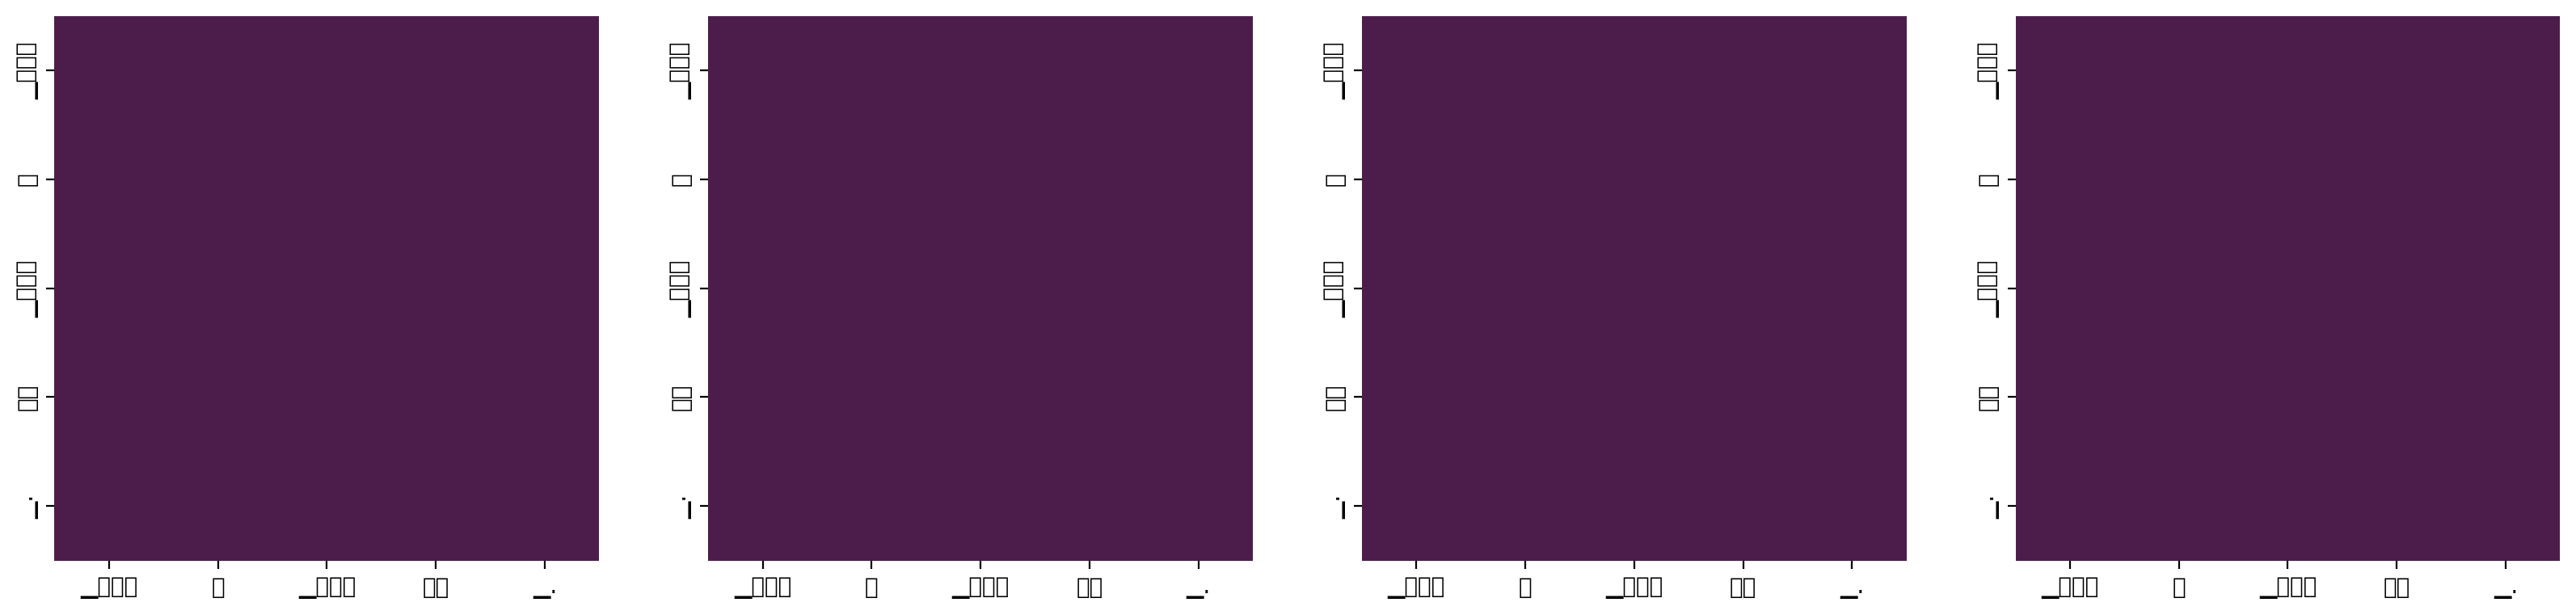

findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s

Encoder Layer 2


findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Fo

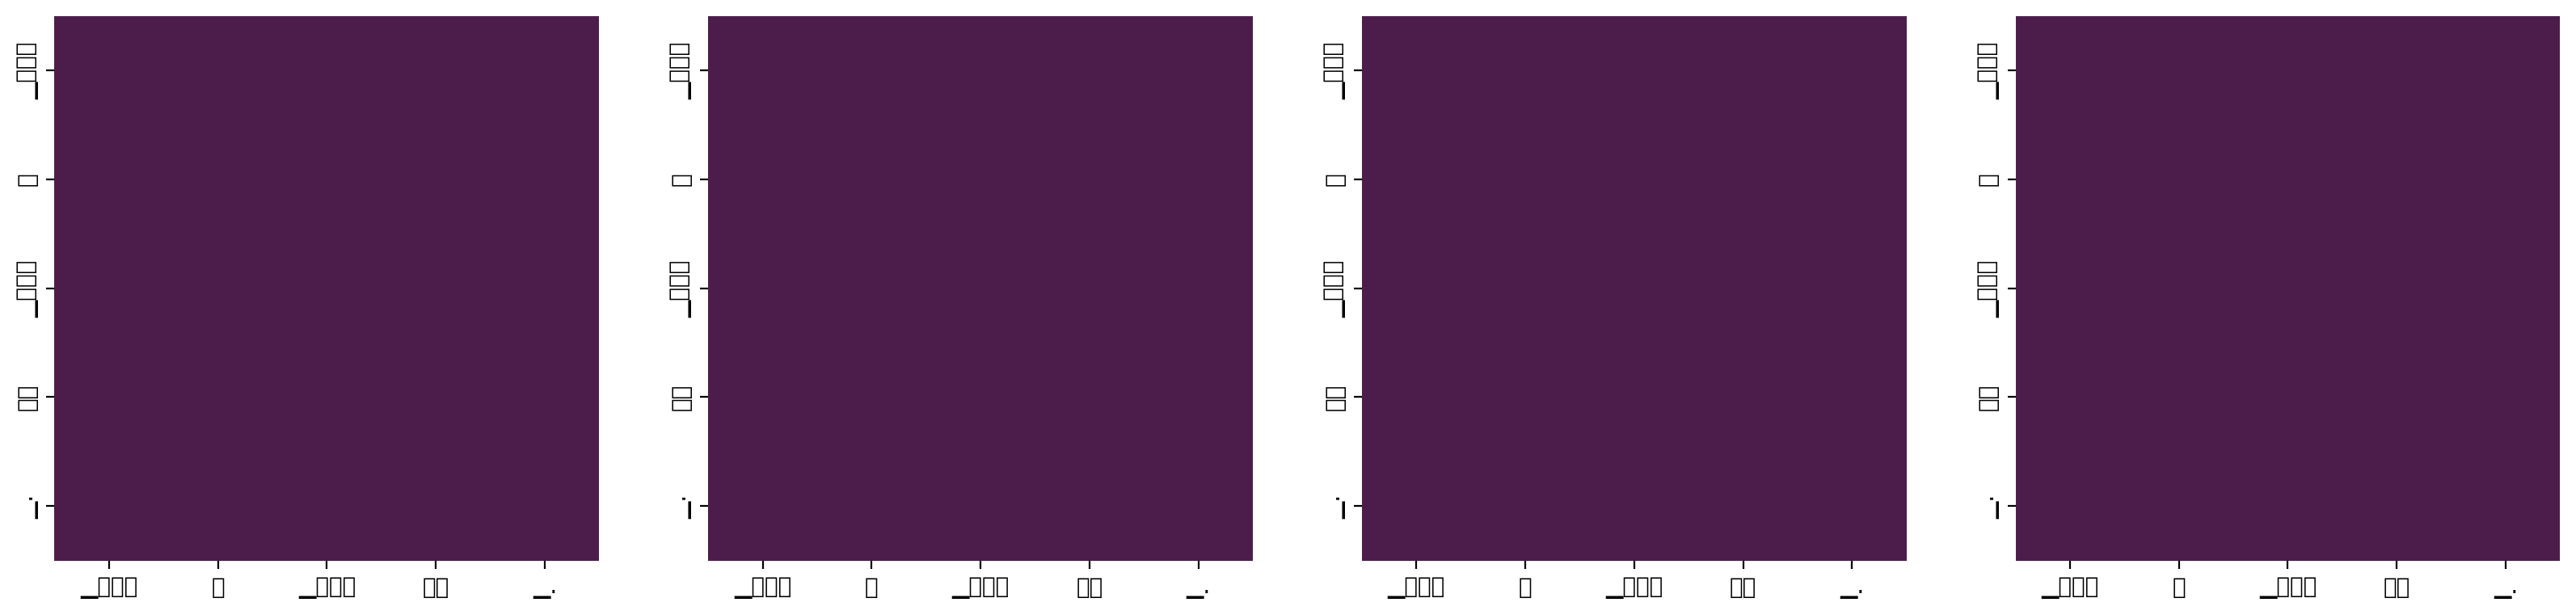

findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Fo

Decoder Self Layer 1


findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Fo

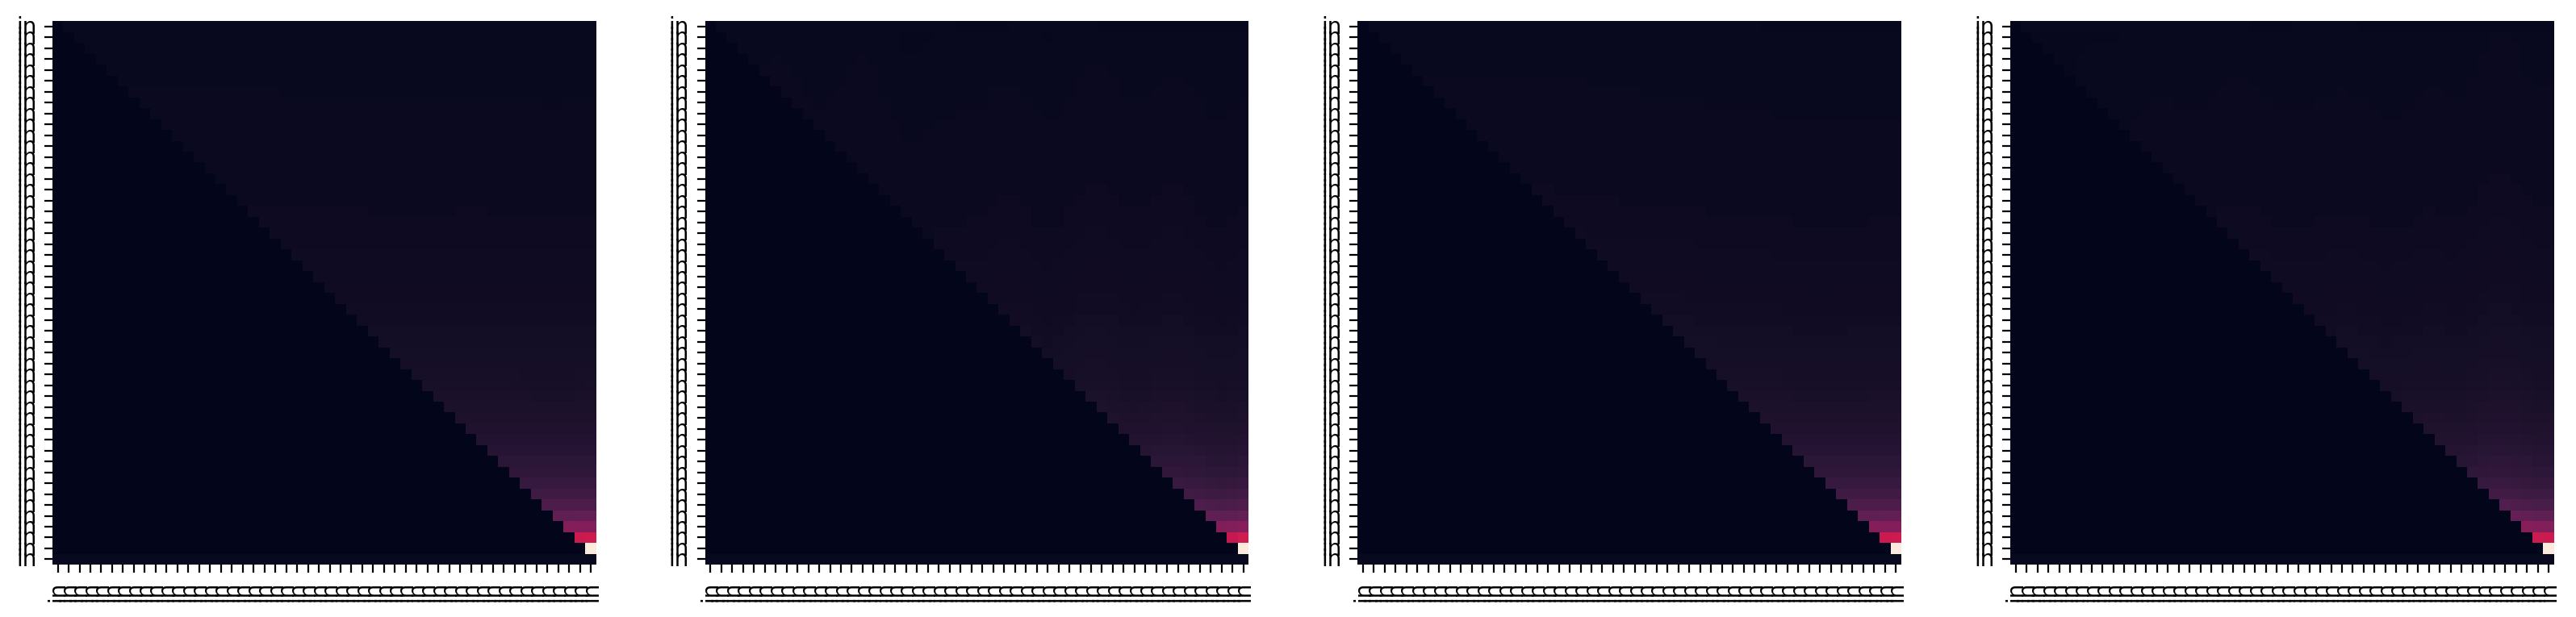

Decoder Src Layer 1


findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Font family 'NanumBarunGothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s

In [ ]:
transformer.eval()
translate("오바마는 대통령이다.", transformer, ko_tokenizer, en_tokenizer, plot_attention=True)

## 📝 프로젝트 회고

### ✅ 잘된 점
- 데이터 정제, SentencePiece 토큰화, 데이터셋 구축을 지시대로 완료했다
- Transformer 내부 모듈(MultiHeadAttention, FFN, EncoderLayer, DecoderLayer)을 하나하나 직접 구현했다
- 학습 루프를 완성하고 20 Epoch 동안 학습을 진행했다
- Attention Map 시각화까지 구현했다
- GPU/CPU 디바이스 불일치 오류를 스스로 해결했다

### 😅 아쉬운 점
- 번역 결과가 `in in in...` 처럼 의미없는 단어가 반복됐다
- Mask 방향 버그(버그1)와 Cross-Attention에 잘못된 마스크 적용(버그2)으로 학습이 제대로 되지 않았다
- 모델이 작고(2 Layer) Epoch가 부족해서 학습이 충분하지 않았다

### 💡 배운 점
- Transformer 구조를 직접 구현하면서 Multi-Head Attention, Positional Encoding의 동작 원리를 이해했다
- `masked_fill` 방향이 잘못되면 유효 토큰을 가리고 PAD 토큰만 attend 하는 치명적인 버그가 생긴다는 것을 배웠다
- Cross-Attention에는 Causal Mask가 아닌 PAD 마스크만 적용해야 한다는 것을 배웠다
- SentencePiece로 한국어/영어 토크나이저를 직접 만들어봤다
- `.to(device)` 의 중요성을 GPU/CPU 불일치 오류를 통해 배웠다

### 🚀 다음엔 이렇게 해볼게
- 버그 2개 수정 후 재학습해서 번역 품질 확인하기
- n_layers를 4로 늘리고 Epoch를 30으로 늘려보기
- warmup_steps를 1000으로 줄여서 학습 안정화하기
- Label Smoothing 적용해보기